# Seaborn 数据可视化学习

Seaborn 是基于 Matplotlib 的高级统计数据可视化库，它提供了更简洁的 API 和更美观的默认样式。在实际的数据分析工作中，我们通常先使用 Pandas 进行数据处理和探索，然后借助 Seaborn 快速生成各种统计图表。Seaborn 与 Matplotlib 的关系密不可分：底层仍然调用 Matplotlib 的绘图函数，但在其基础上封装了大量便捷功能，使得创建复杂图表变得轻而易举。本笔记将系统介绍 Seaborn 的核心绘图功能，并通过企鹅数据集（penguins.csv）进行实战演示。

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体支持
plt.rcParams["font.sans-serif"] = ["SimHei", "STHeiti", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

# 加载企鹅数据集
penguins = pd.read_csv("data/penguins.csv")
penguins.dropna(inplace=True)
print(f"数据集形状: {penguins.shape}")
print(f"\n数据集前5行:")
penguins.head()

数据集形状: (333, 7)

数据集前5行:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


## 分布图表

### 直方图（Histplot）

直方图是展示数值型变量分布最常用的方式之一。它将数据划分成若干个等宽的区间（bins），然后统计每个区间内数据点的数量。Seaborn 的 histplot 函数不仅能绘制基本的直方图，还支持核密度估计曲线的叠加（kde=True），以及按类别分组显示（hue 参数）。通过设置 stat 参数，我们还可以将纵轴切换为密度或频率等不同统计量。

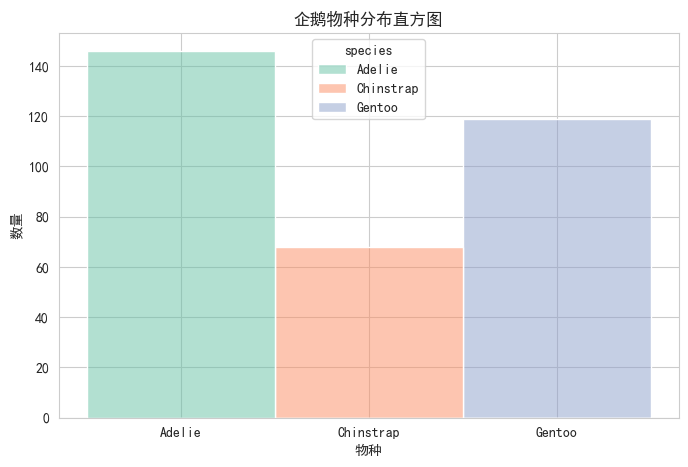

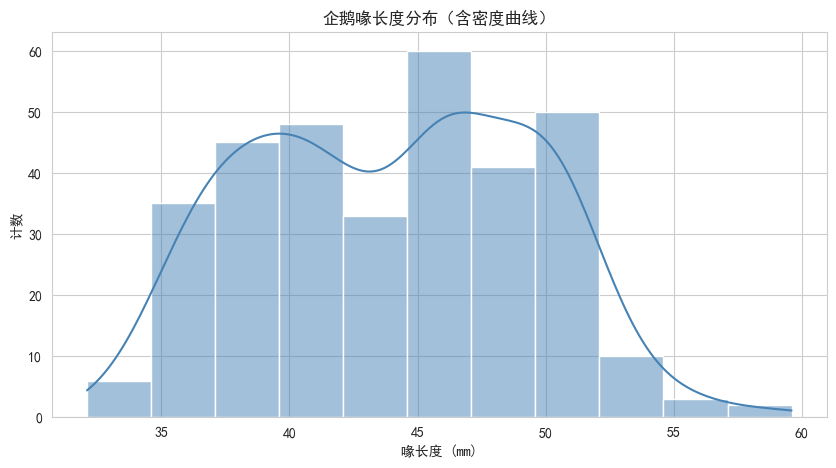

In [2]:
# 基本直方图：展示不同企鹅物种的分布
plt.figure(figsize=(8, 5))
sns.histplot(data=penguins, x="species", hue="species", palette="Set2")
plt.title("企鹅物种分布直方图")
plt.xlabel("物种")
plt.ylabel("数量")
plt.show()

# 带核密度估计的直方图：展示喙长度的分布
plt.figure(figsize=(10, 5))
sns.histplot(data=penguins, x="bill_length_mm", kde=True, color="steelblue")
plt.title("企鹅喙长度分布（含密度曲线）")
plt.xlabel("喙长度 (mm)")
plt.ylabel("计数")
plt.show()

### 核密度估计图（KDE Plot）

核密度估计（Kernel Density Estimate）是一种非参数化的概率密度估计方法。与直方图相比，KDE 生成的曲线更加平滑连续，能够更直观地呈现数据分布的形态。Seaborn 的 kdeplot 会将每个数据点视为一个核（通常使用高斯核），然后将所有核叠加得到最终的密度曲线。这种方法特别适合比较多个组别的分布差异。

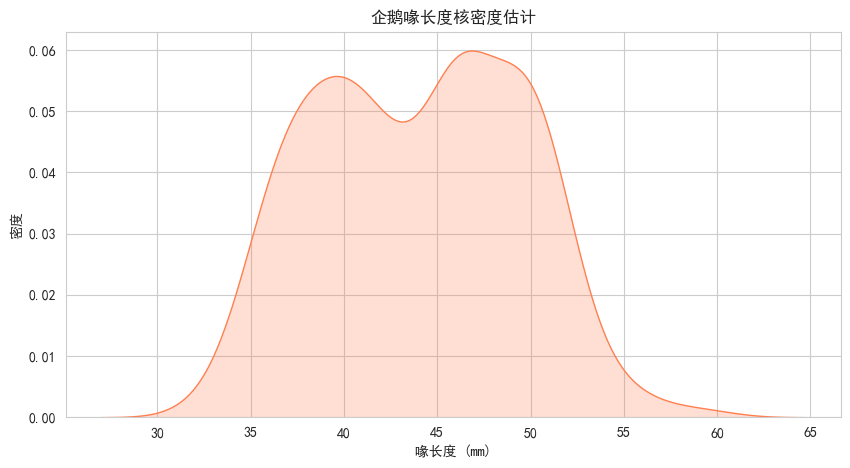

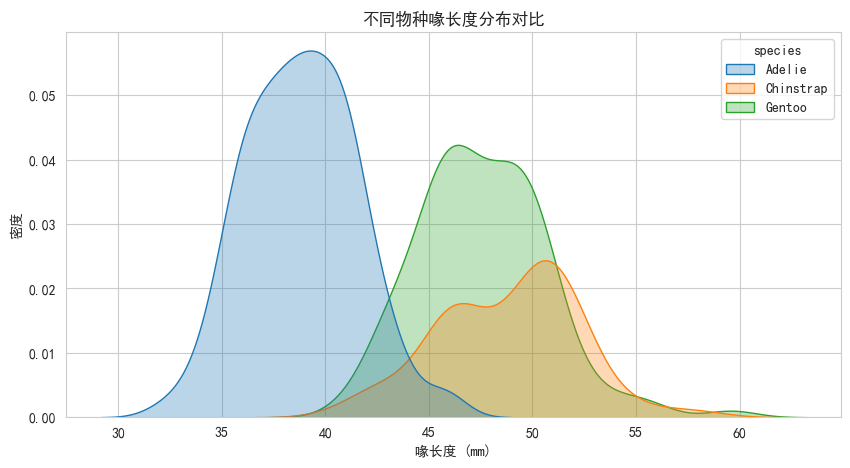

In [3]:
# 基本 KDE 图
plt.figure(figsize=(10, 5))
sns.kdeplot(data=penguins, x="bill_length_mm", fill=True, color="coral")
plt.title("企鹅喙长度核密度估计")
plt.xlabel("喙长度 (mm)")
plt.ylabel("密度")
plt.show()

# 按物种分组的 KDE 图
plt.figure(figsize=(10, 5))
sns.kdeplot(data=penguins, x="bill_length_mm", hue="species", fill=True, alpha=0.3)
plt.title("不同物种喙长度分布对比")
plt.xlabel("喙长度 (mm)")
plt.ylabel("密度")
plt.show()

### rugplot（地毯图）

地毯图是一种简单的辅助图表，用于在坐标轴上标记每个数据点的确切位置。通常与其他图表（如 KDE 或散点图）配合使用，可以帮助我们了解数据的稀疏程度和聚集情况。在 kdeplot 或 histplot 中，数据密集的区域地毯线会显得更密集，直观反映出数据的分布密度。

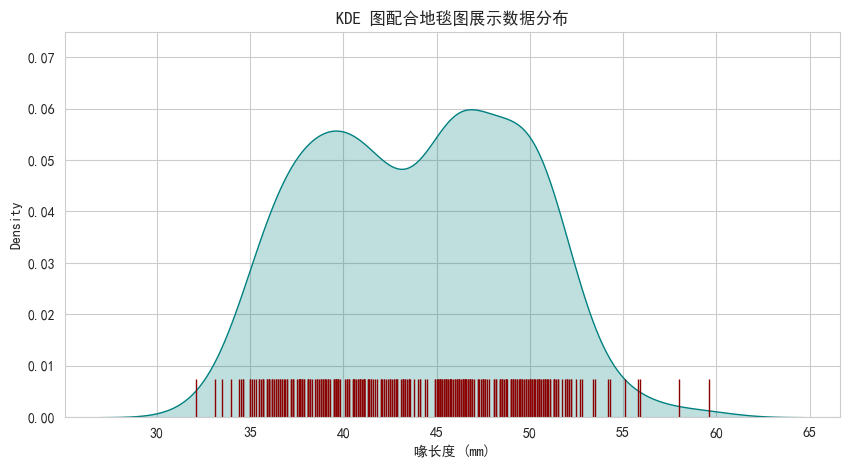

In [4]:
# KDE 图配合地毯图使用
plt.figure(figsize=(10, 5))
sns.kdeplot(data=penguins, x="bill_length_mm", fill=True, color="teal")
sns.rugplot(data=penguins, x="bill_length_mm", color="darkred", height=0.1)
plt.title("KDE 图配合地毯图展示数据分布")
plt.xlabel("喙长度 (mm)")
plt.show()

## 计数图表

### 计数图（Countplot）

计数图用于展示分类变量的各水平（类别）对应的样本数量，是分析分类数据分布最基本的工具。每个类别对应一根柱子，柱子的高度直接反映该类别的频数。通过 hue 参数，我们还可以在同一个图表中进一步按另一个分类变量进行分组展示。

C:\Users\meytao\AppData\Local\Temp\ipykernel_25388\3978866327.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=penguins, x="island", palette="muted")


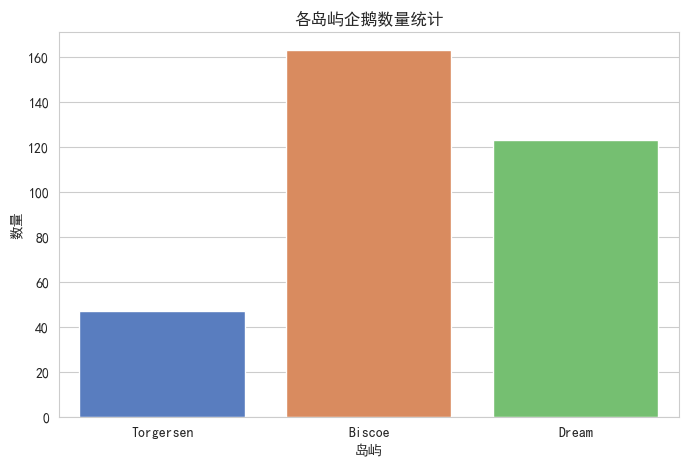

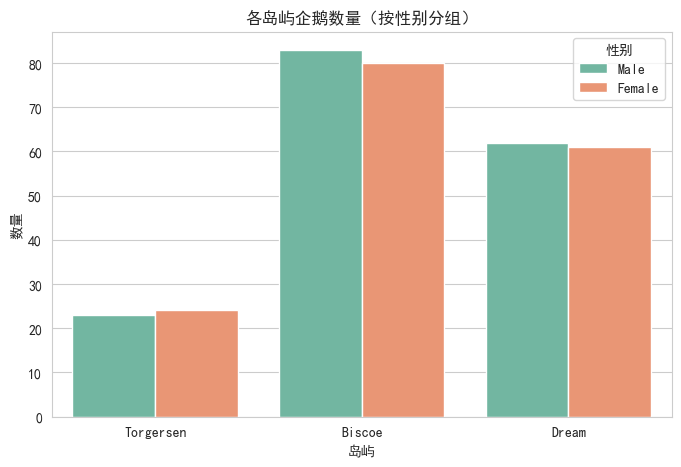

In [5]:
# 基本计数图：各岛屿企鹅数量
plt.figure(figsize=(8, 5))
sns.countplot(data=penguins, x="island", palette="muted")
plt.title("各岛屿企鹅数量统计")
plt.xlabel("岛屿")
plt.ylabel("数量")
plt.show()

# 按性别分组的计数图
plt.figure(figsize=(8, 5))
sns.countplot(data=penguins, x="island", hue="sex", palette="Set2")
plt.title("各岛屿企鹅数量（按性别分组）")
plt.xlabel("岛屿")
plt.ylabel("数量")
plt.legend(title="性别")
plt.show()

### 条形图（Barplot）

条形图与计数图类似，但它的纵轴可以是任意聚合统计量（均值、中位数、标准差等），而不仅仅局限于计数。barplot 还会自动计算并显示误差棒（error bar），默认为 95% 置信区间。通过设置 estimator 参数，我们可以指定使用何种统计函数来计算每个类别的值。

C:\Users\meytao\AppData\Local\Temp\ipykernel_25388\565917315.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=penguins, x="species", y="bill_length_mm", estimator="mean", errorbar=None, palette="Set3")


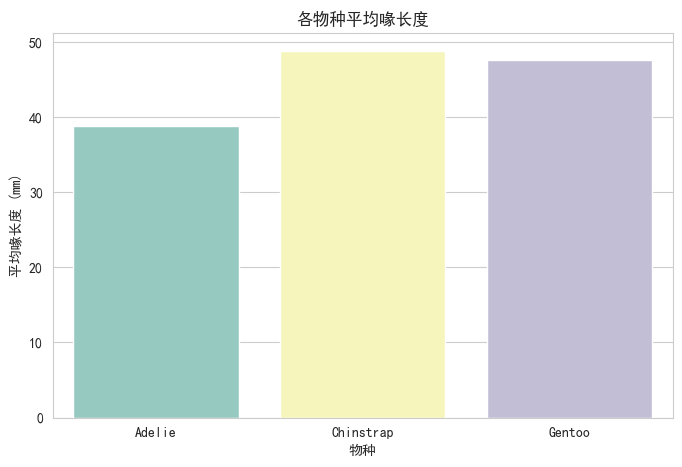

C:\Users\meytao\AppData\Local\Temp\ipykernel_25388\565917315.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=penguins, x="species", y="bill_length_mm", estimator="mean", palette="viridis")


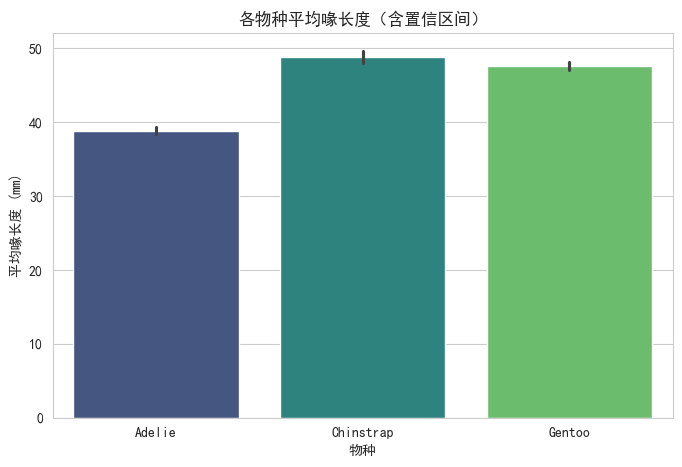

In [6]:
# 条形图：各物种平均喙长度
plt.figure(figsize=(8, 5))
sns.barplot(data=penguins, x="species", y="bill_length_mm", estimator="mean", errorbar=None, palette="Set3")
plt.title("各物种平均喙长度")
plt.xlabel("物种")
plt.ylabel("平均喙长度 (mm)")
plt.show()

# 带误差棒的条形图
plt.figure(figsize=(8, 5))
sns.barplot(data=penguins, x="species", y="bill_length_mm", estimator="mean", palette="viridis")
plt.title("各物种平均喙长度（含置信区间）")
plt.xlabel("物种")
plt.ylabel("平均喙长度 (mm)")
plt.show()

## 散点图及相关图表

### 基本散点图（Scatterplot）

散点图是展示两个连续变量之间关系的经典方式。每个数据点以点的形式呈现在坐标系中，其 x 坐标和 y 坐标分别对应两个变量的值。通过 hue、size、style 等参数，我们可以添加更多维度的信息，使得散点图能够同时展示三个甚至更多变量之间的关系。

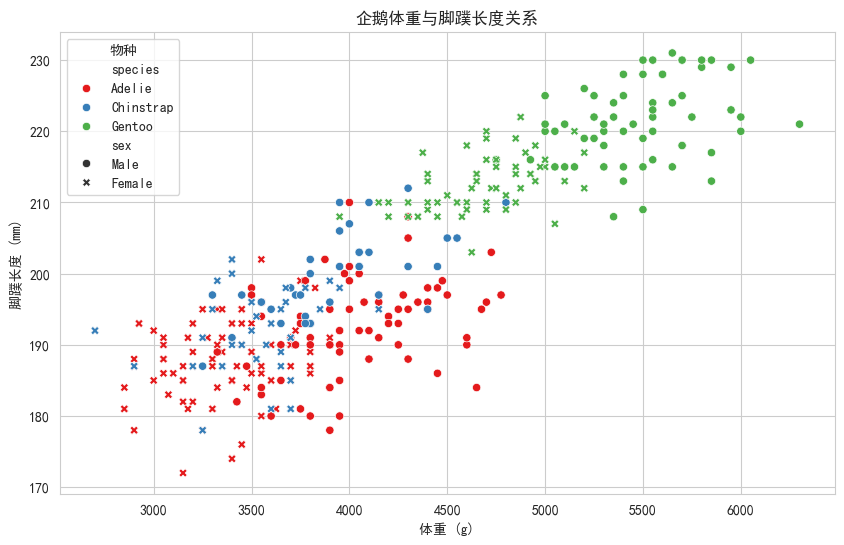

In [7]:
# 基本散点图：体重与脚蹼长度的关系
plt.figure(figsize=(10, 6))
sns.scatterplot(data=penguins, x="body_mass_g", y="flipper_length_mm", hue="species", style="sex", palette="Set1")
plt.title("企鹅体重与脚蹼长度关系")
plt.xlabel("体重 (g)")
plt.ylabel("脚蹼长度 (mm)")
plt.legend(title="物种", loc="upper left")
plt.show()

### 联合图（Jointplot）

联合图是散点图与边缘分布图的组合，在图的中心展示两个变量的联合分布（散点图或六边形图），在边缘展示各自的单变量分布（直方图或 KDE）。通过 kind 参数，我们可以选择不同类型的中心图：scatter（散点）、hex（六边形）、kde（核密度）、reg（带回归线的散点）。

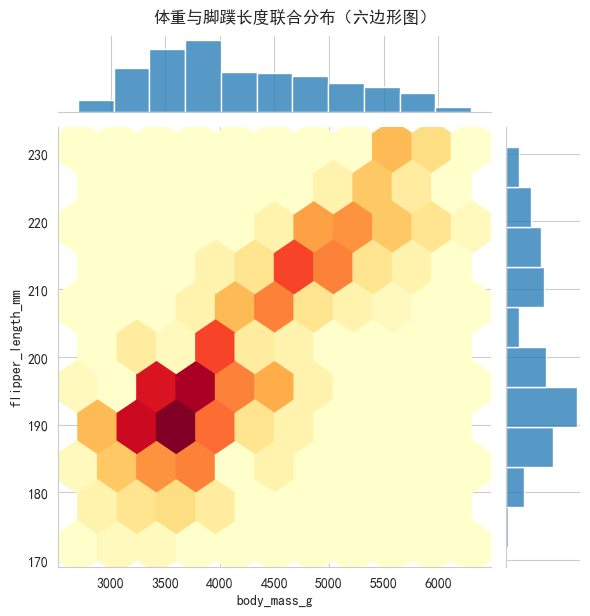

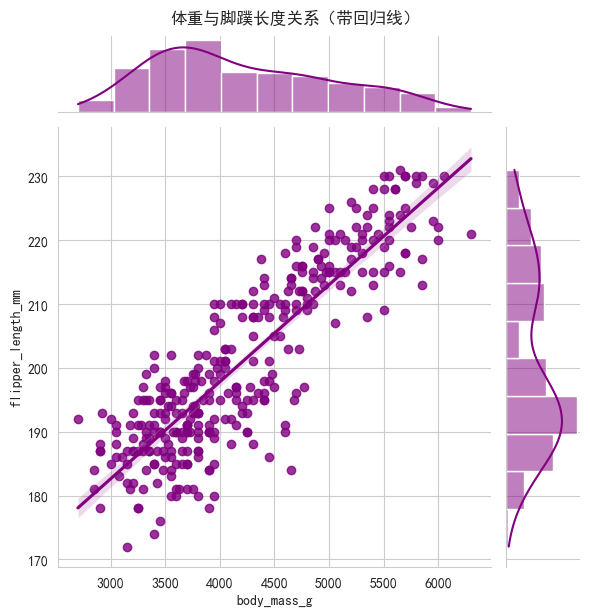

In [8]:
# 六边形联合图：适合大数据量的密度展示
sns.jointplot(data=penguins, x="body_mass_g", y="flipper_length_mm", kind="hex", cmap="YlOrRd")
plt.suptitle("体重与脚蹼长度联合分布（六边形图）", y=1.02)
plt.show()

# 带回归线的联合图
sns.jointplot(data=penguins, x="body_mass_g", y="flipper_length_mm", kind="reg", color="purple")
plt.suptitle("体重与脚蹼长度关系（带回归线）", y=1.02)
plt.show()

### 成对关系图（Pairplot）

成对关系图用于展示数据集中多个变量之间的两两关系。对角线位置显示每个变量自身的分布（非严格对角线时为直方图或 KDE），其他位置为两个变量两两组合的散点图。通过 hue 参数，可以按类别给不同组的数据点着色，便于比较各类别在各变量上的差异。pairplot 是探索多维数据时最常用的可视化工具之一。

D:\coding\PythonProject\data_analysis\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
D:\coding\PythonProject\data_analysis\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
D:\coding\PythonProject\data_analysis\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
D:\coding\PythonProject\data_analysis\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
D:\coding\PythonProject\data_analysis\.venv\Lib\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
D:\coding\PythonProj

<Figure size 1000x800 with 0 Axes>

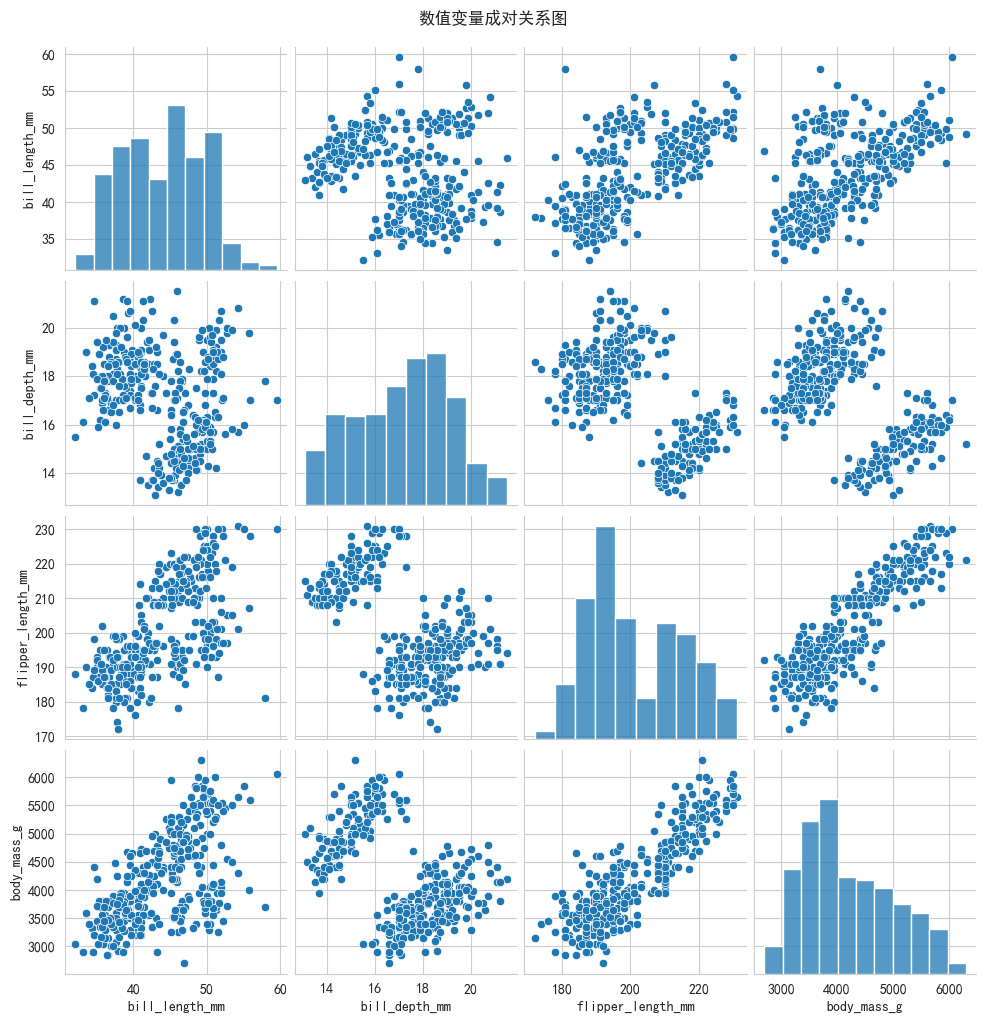

<Figure size 1000x800 with 0 Axes>

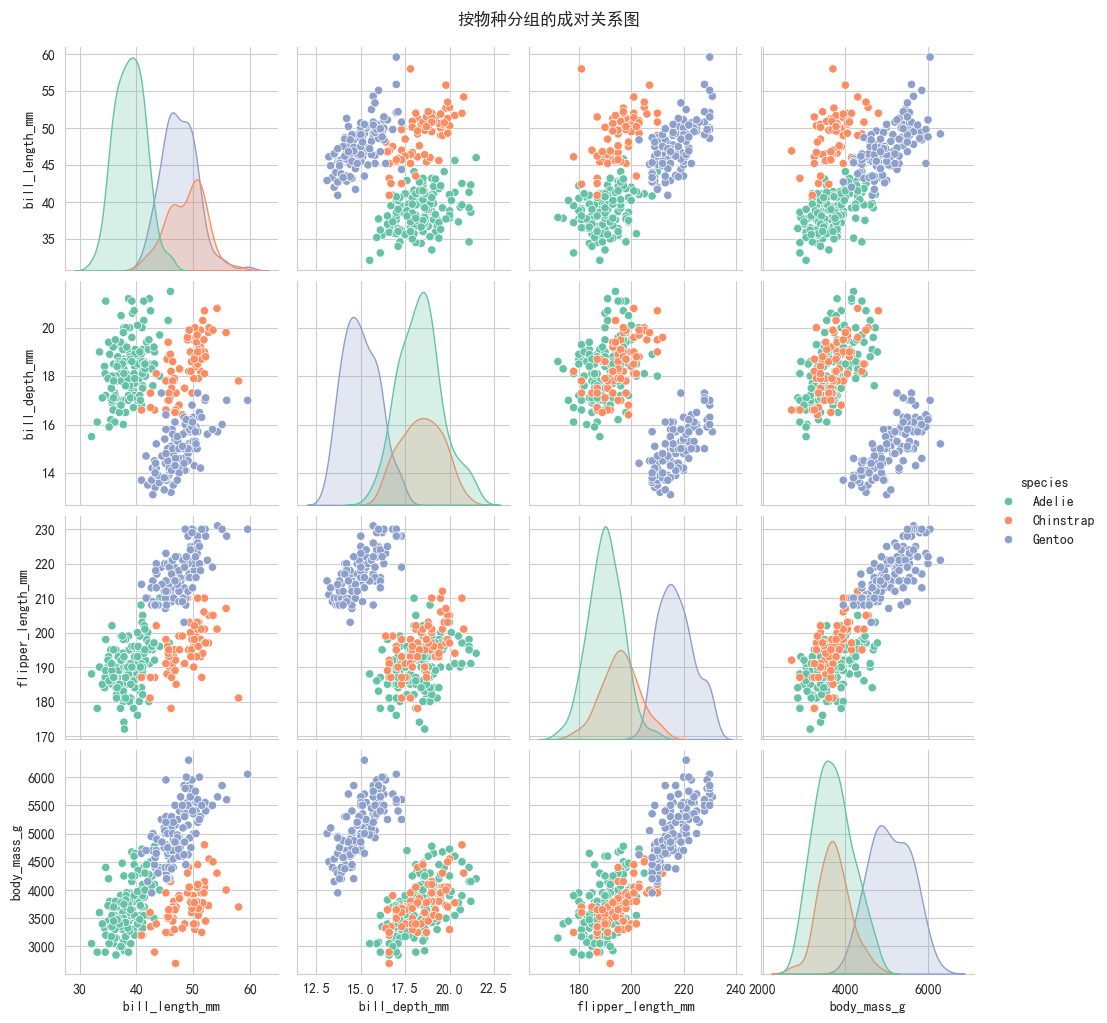

In [9]:
# 选择部分数值变量进行成对关系展示
num_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
plt.figure(figsize=(10, 8))
sns.pairplot(data=penguins[num_cols], palette="husl")
plt.suptitle("数值变量成对关系图", y=1.02)
plt.show()

# 按物种着色的成对关系图
plt.figure(figsize=(10, 8))
sns.pairplot(data=penguins, hue="species", vars=num_cols, palette="Set2")
plt.suptitle("按物种分组的成对关系图", y=1.02)
plt.show()

## 二维核密度估计图

二维核密度估计图用于展示两个连续变量联合概率密度分布。与一维 KDE 类似，二维 KDE 将每个数据点视为二维空间中的一个核，然后叠加所有核的贡献得到平滑的密度曲面。通过 fill=True 可以将密度值映射为填充颜色生成等高线图，通过 cbar=True 可以在图侧显示颜色条表示密度值。这种图表特别适合发现数据中的聚集模式和分布热点。

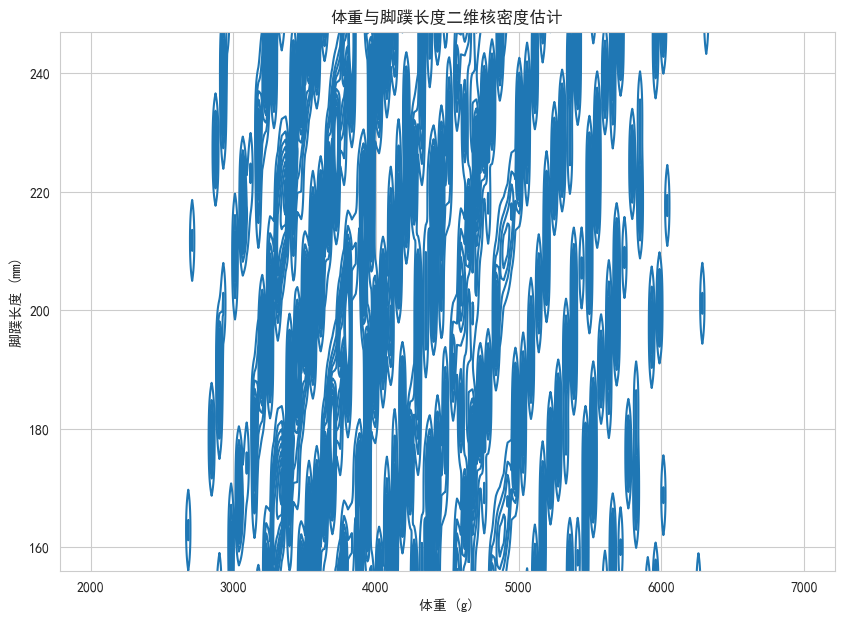

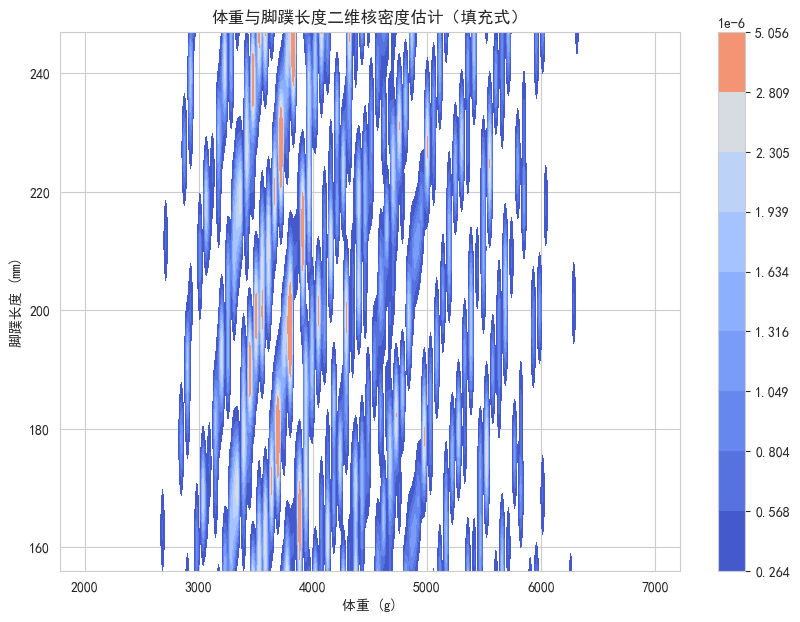

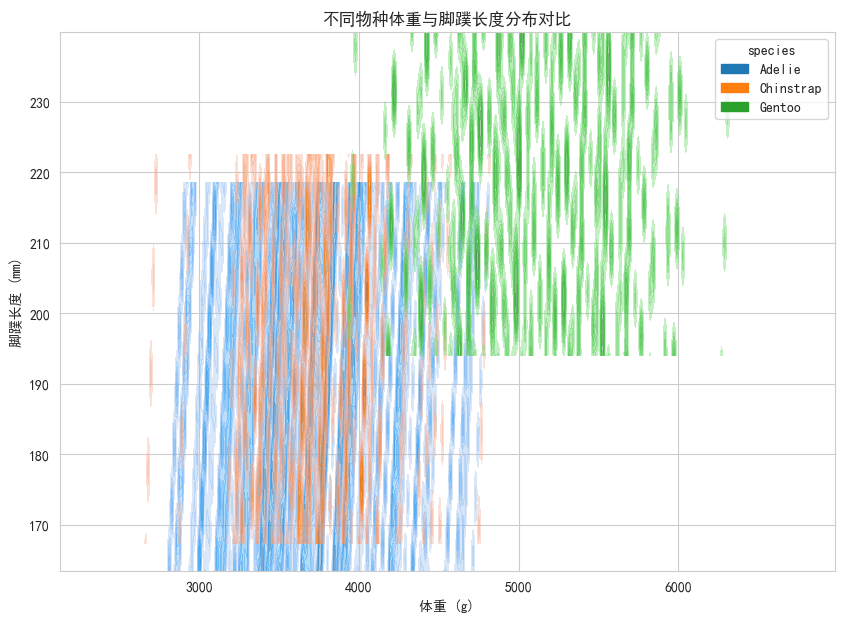

In [10]:
# 基本二维 KDE 图
plt.figure(figsize=(10, 7))
sns.kdeplot(data=penguins, x="body_mass_g", y="flipper_length_mm")
plt.title("体重与脚蹼长度二维核密度估计")
plt.xlabel("体重 (g)")
plt.ylabel("脚蹼长度 (mm)")
plt.show()

# 填充式二维 KDE 图（带颜色条）
plt.figure(figsize=(10, 7))
sns.kdeplot(data=penguins, x="body_mass_g", y="flipper_length_mm", fill=True, cbar=True, cmap="coolwarm")
plt.title("体重与脚蹼长度二维核密度估计（填充式）")
plt.xlabel("体重 (g)")
plt.ylabel("脚蹼长度 (mm)")
plt.show()

# 按物种分组且填充的二维 KDE
plt.figure(figsize=(10, 7))
sns.kdeplot(data=penguins, x="body_mass_g", y="flipper_length_mm", hue="species", fill=True, alpha=0.4)
plt.title("不同物种体重与脚蹼长度分布对比")
plt.xlabel("体重 (g)")
plt.ylabel("脚蹼长度 (mm)")
plt.show()

## 箱线图（Box Plot）

箱线图是一种用来展示数据分布特征的经典图表，能够同时显示数据的最小值、下四分位数（Q1）、中位数、上四分位数（Q3）、最大值以及可能的异常值。箱子的高度反映了数据的四分位距（IQR = Q3 - Q1），胡须通常延伸到 1.5 倍 ITR 范围内的最远数据点，超出这个范围的点被视为异常值。箱线图特别适合多个组别之间的分布对比。

C:\Users\meytao\AppData\Local\Temp\ipykernel_25388\2929525444.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins, x="species", y="bill_length_mm", palette="Set3")


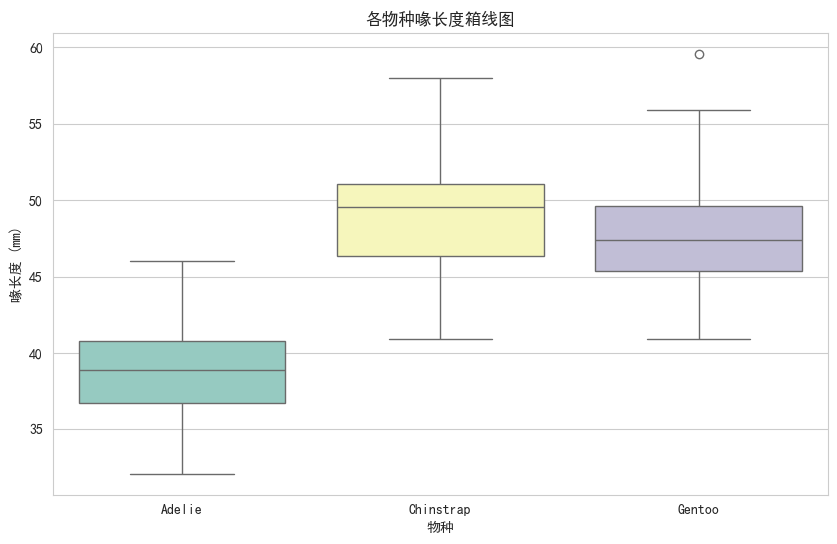

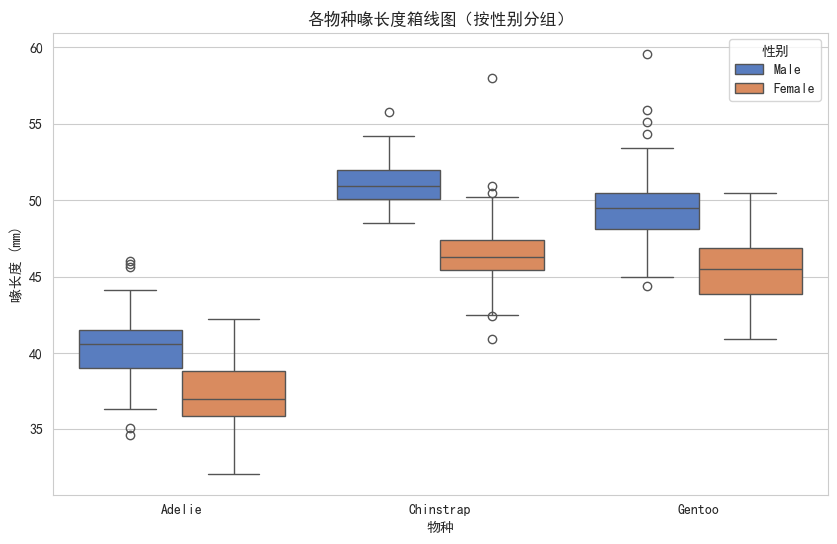

In [11]:
# 基本箱线图：各物种喙长度分布
plt.figure(figsize=(10, 6))
sns.boxplot(data=penguins, x="species", y="bill_length_mm", palette="Set3")
plt.title("各物种喙长度箱线图")
plt.xlabel("物种")
plt.ylabel("喙长度 (mm)")
plt.show()

# 按性别分组的箱线图
plt.figure(figsize=(10, 6))
sns.boxplot(data=penguins, x="species", y="bill_length_mm", hue="sex", palette="muted")
plt.title("各物种喙长度箱线图（按性别分组）")
plt.xlabel("物种")
plt.ylabel("喙长度 (mm)")
plt.legend(title="性别")
plt.show()

## 小提琴图（Violin Plot）

小提琴图是箱线图与核密度估计图的结合体。它在外形上类似于一把小提琴，中间的黑色粗线表示四分位数，延伸的细线表示胡须，两侧的彩色部分则是由 KDE 生成的密度曲线。这种图表的优势在于能够同时展示数据的分布形态和统计特征，特别适合比较多个组别分布的差异。当某个组的样本量较少时，小提琴图可能会出现不平滑的边缘。

C:\Users\meytao\AppData\Local\Temp\ipykernel_25388\1772507129.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=penguins, x="species", y="bill_length_mm", palette="Set2")


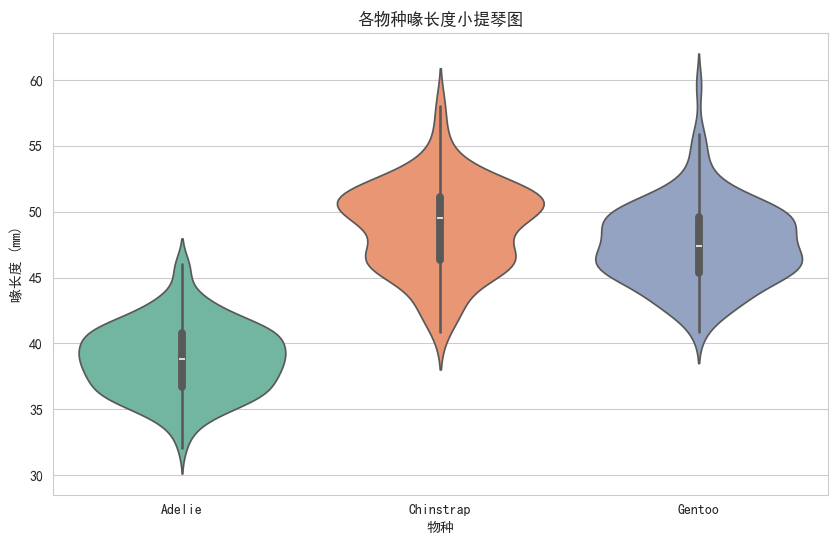

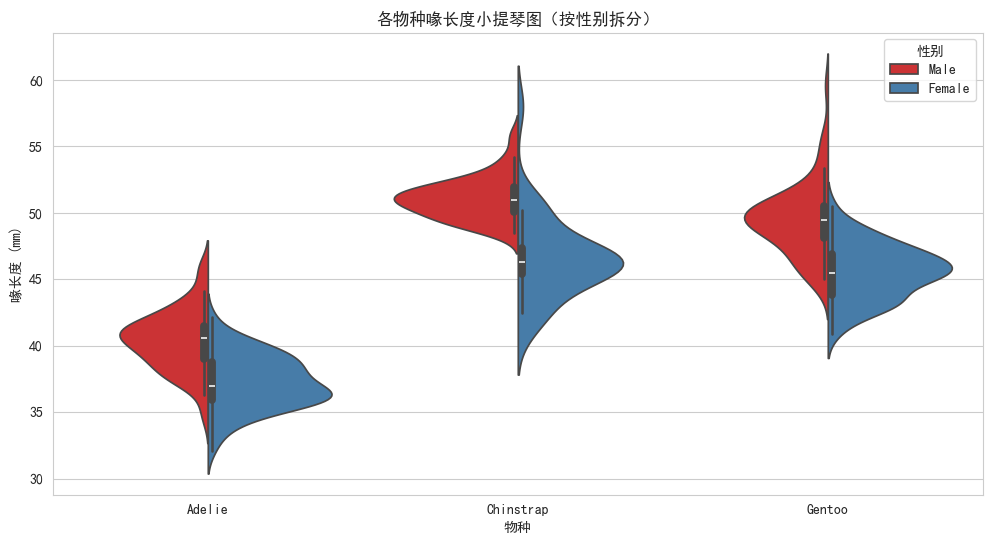

In [12]:
# 基本小提琴图
plt.figure(figsize=(10, 6))
sns.violinplot(data=penguins, x="species", y="bill_length_mm", palette="Set2")
plt.title("各物种喙长度小提琴图")
plt.xlabel("物种")
plt.ylabel("喙长度 (mm)")
plt.show()

# 按性别分组的小提琴图
plt.figure(figsize=(12, 6))
sns.violinplot(data=penguins, x="species", y="bill_length_mm", hue="sex", split=True, palette="Set1")
plt.title("各物种喙长度小提琴图（按性别拆分）")
plt.xlabel("物种")
plt.ylabel("喙长度 (mm)")
plt.legend(title="性别")
plt.show()

## 热力图（Heatmap）

热力图通过颜色深浅来表示数据矩阵中数值的大小，是展示相关性矩阵、混淆矩阵或任何二维表格数据的理想工具。Seaborn 的 heatmap 函数提供了丰富的自定义选项，包括颜色映射、单元格标注、数值格式化、分割线设置等。在数据分析中，热力图最常见的用途是查看变量之间的相关系数矩阵。

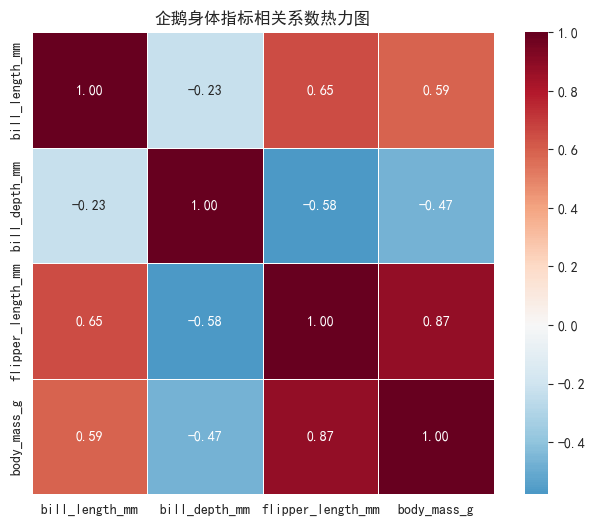

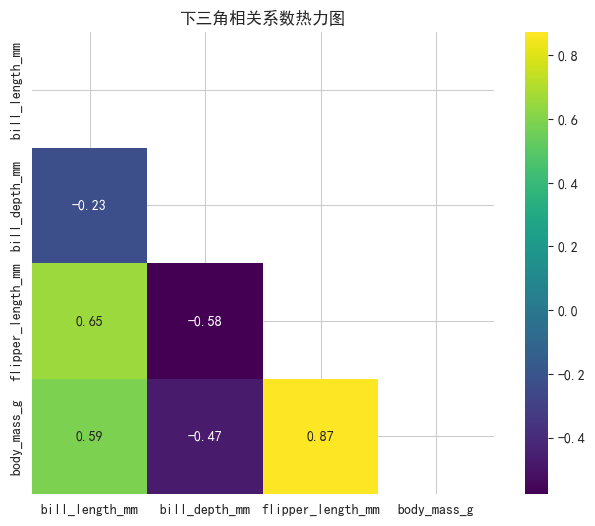

In [13]:
# 计算数值变量的相关系数矩阵
num_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
corr_matrix = penguins[num_cols].corr()

# 绘制热力图
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, linewidths=0.5)
plt.title("企鹅身体指标相关系数热力图")
plt.show()

# 使用不同颜色方案的带掩码热力图
plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="viridis", square=True)
plt.title("下三角相关系数热力图")
plt.show()

## 样式与配色

Seaborn 提供了多种内置主题（style）和配色方案（palette），可以轻松改变图表的整体外观风格。常用的主题包括 white、dark、whitegrid、darkgrid，通过 set_style 函数设置。配色方案则通过 set_palette 函数切换，Seaborn 内置了 husl、Set2、muted、deep、pastel、dark 等多种调色板，也可以使用 Matplotlib 的所有_colormaps。对于分类数据，选择对比度高的配色方案有助于区分不同类别。

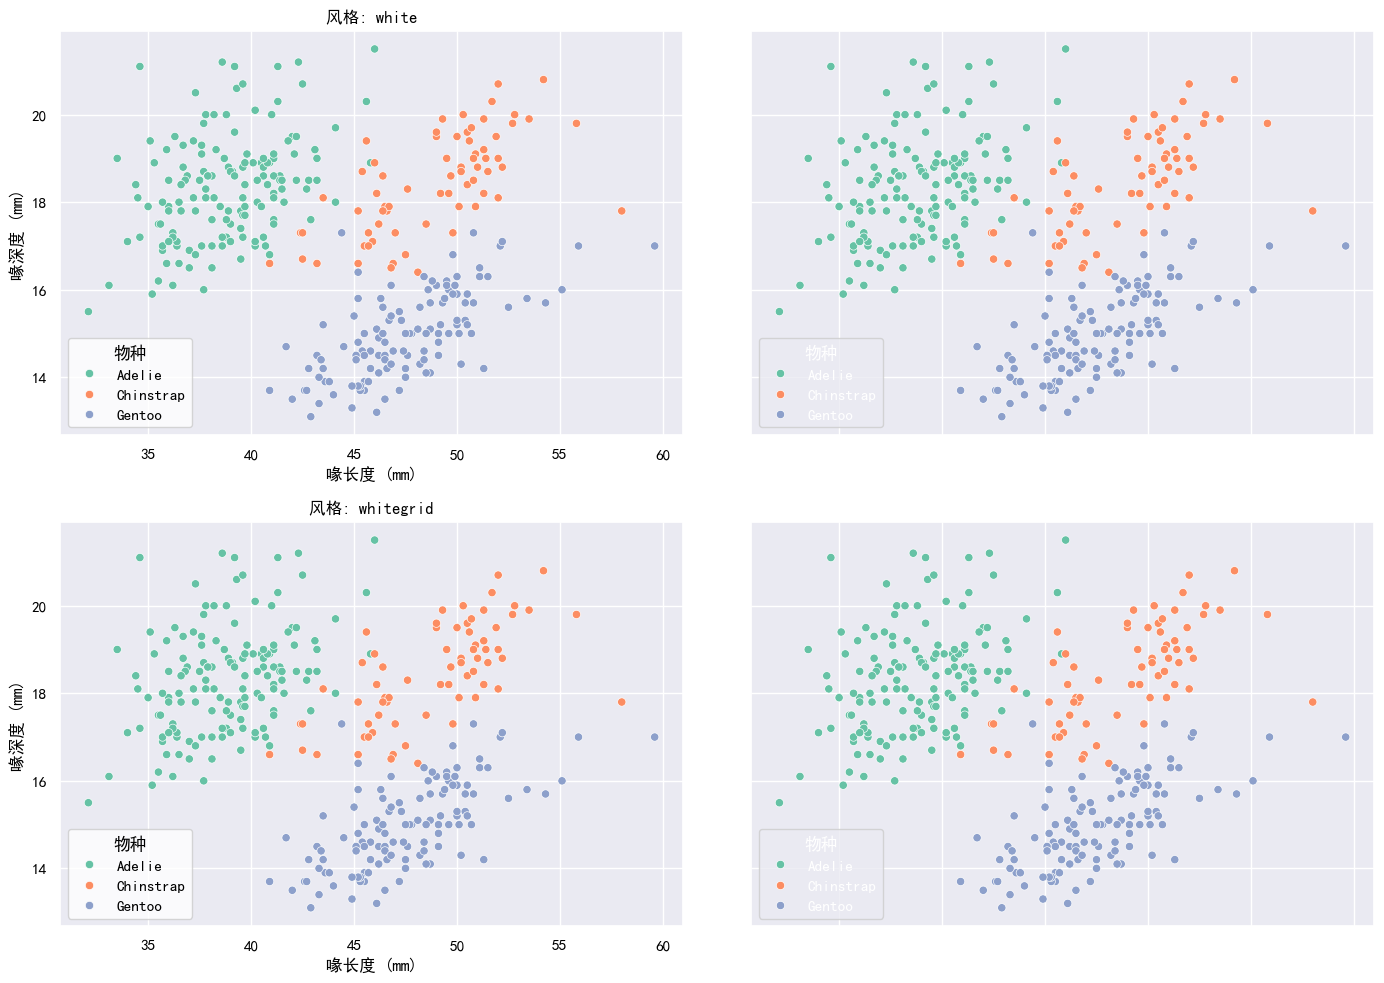

C:\Users\meytao\AppData\Local\Temp\ipykernel_25388\1958573766.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=penguins, x="species", y="body_mass_g", estimator="mean", errorbar=None, ax=axes[i], palette=palette)
C:\Users\meytao\AppData\Local\Temp\ipykernel_25388\1958573766.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=penguins, x="species", y="body_mass_g", estimator="mean", errorbar=None, ax=axes[i], palette=palette)
C:\Users\meytao\AppData\Local\Temp\ipykernel_25388\1958573766.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  

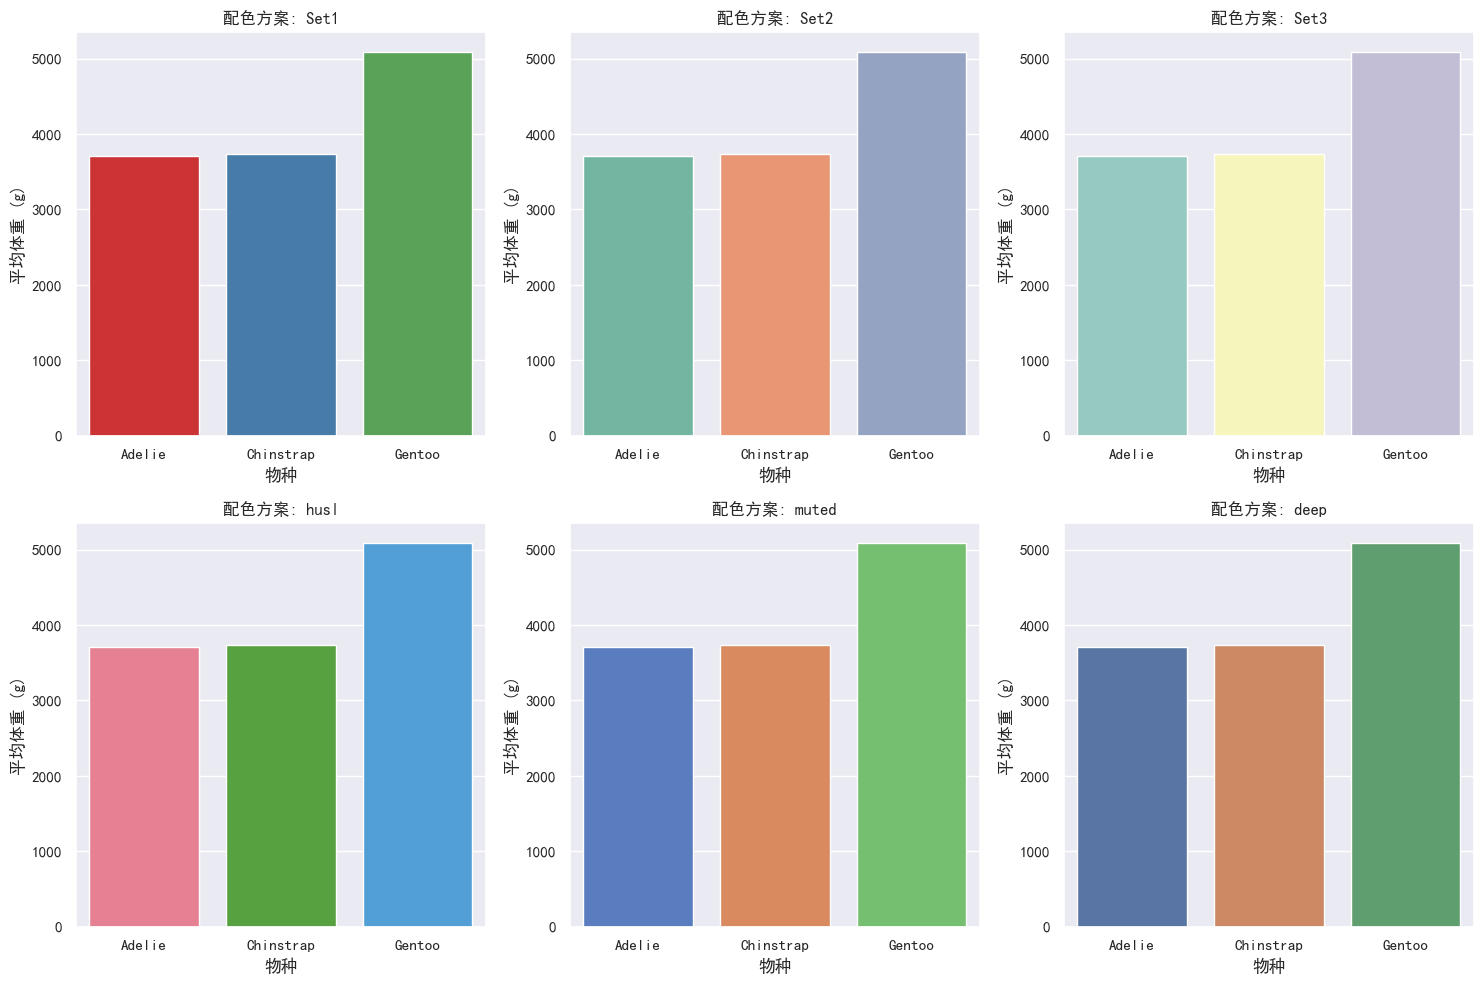

In [17]:
# 演示不同主题风格
styles = ["white", "dark", "whitegrid", "darkgrid"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, style in enumerate(styles):
    sns.set_style(style)
    # 深色主题需要调整文字颜色
    title_color = 'white' if style in ['dark', 'darkgrid'] else 'black'
    sns.scatterplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species", ax=axes[i], palette="Set2")
    axes[i].set_title(f"风格: {style}", color=title_color)
    axes[i].set_xlabel("喙长度 (mm)", color=title_color)
    axes[i].set_ylabel("喙深度 (mm)", color=title_color)
    # 调整刻度标签颜色
    axes[i].tick_params(colors=title_color)
    # 图例在深色背景下也需要调整
    if axes[i].get_legend():
        axes[i].get_legend().set_title("物种")
        for text in axes[i].get_legend().get_texts():
            text.set_color(title_color)
        axes[i].get_legend().get_title().set_color(title_color)
# 设置中文字体，不同系统可用的字体名可能不同
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
# 解决负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False
plt.tight_layout()
plt.show()

# 演示不同配色方案
palettes = ["Set1", "Set2", "Set3", "husl", "muted", "deep"]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, palette in enumerate(palettes):
    sns.barplot(data=penguins, x="species", y="body_mass_g", estimator="mean", errorbar=None, ax=axes[i], palette=palette)
    axes[i].set_title(f"配色方案: {palette}")
    axes[i].set_xlabel("物种")
    axes[i].set_ylabel("平均体重 (g)")
# 设置中文字体，不同系统可用的字体名可能不同
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
# 解决负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False
plt.tight_layout()
plt.show()

# 恢复默认样式
sns.set_theme()

## 综合案例：企鹅数据全面分析

下面我们综合运用 Seaborn 的各种图表类型，对企鹅数据集进行全面的探索性分析。我们将从多个角度（物种差异、身体指标相关性、岛屿分布等）揭示数据中隐藏的规律和模式。

C:\Users\meytao\AppData\Local\Temp\ipykernel_25388\3491007928.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins, x="species", y="flipper_length_mm", ax=axes[0, 1], palette="Set3")


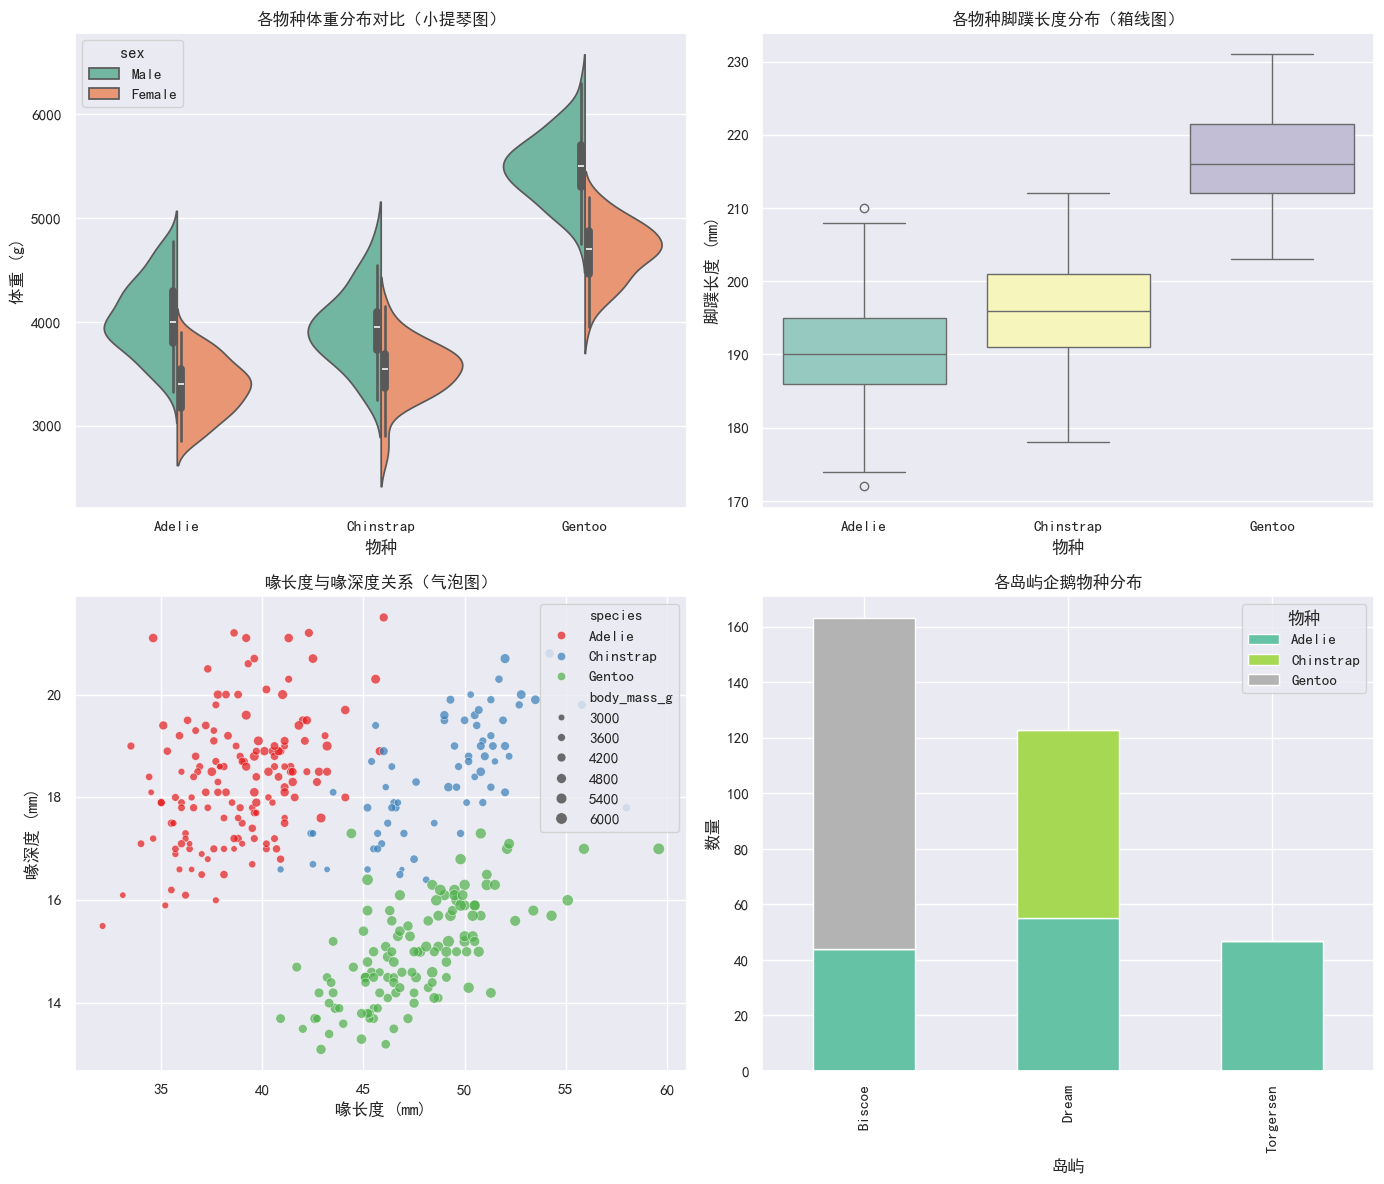

In [19]:
# 综合分析图 1：物种身体指标对比
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1.1 各物种体重分布小提琴图
sns.violinplot(data=penguins, x="species", y="body_mass_g", hue="sex", split=True, ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("各物种体重分布对比（小提琴图）")
axes[0, 0].set_xlabel("物种")
axes[0, 0].set_ylabel("体重 (g)")

# 1.2 各物种脚蹼长度箱线图
sns.boxplot(data=penguins, x="species", y="flipper_length_mm", ax=axes[0, 1], palette="Set3")
axes[0, 1].set_title("各物种脚蹼长度分布（箱线图）")
axes[0, 1].set_xlabel("物种")
axes[0, 1].set_ylabel("脚蹼长度 (mm)")

# 1.3 喙长度与喙深度关系散点图
sns.scatterplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species", size="body_mass_g", ax=axes[1, 0], palette="Set1", alpha=0.7)
axes[1, 0].set_title("喙长度与喙深度关系（气泡图）")
axes[1, 0].set_xlabel("喙长度 (mm)")
axes[1, 0].set_ylabel("喙深度 (mm)")

# 1.4 各岛屿企鹅数量堆叠条形图
island_species = penguins.groupby(["island", "species"]).size().unstack()
island_species.plot(kind="bar", stacked=True, ax=axes[1, 1], colormap="Set2")
axes[1, 1].set_title("各岛屿企鹅物种分布")
axes[1, 1].set_xlabel("岛屿")
axes[1, 1].set_ylabel("数量")
axes[1, 1].legend(title="物种")

# 设置中文字体，不同系统可用的字体名可能不同
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
# 解决负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

plt.tight_layout()
plt.show()

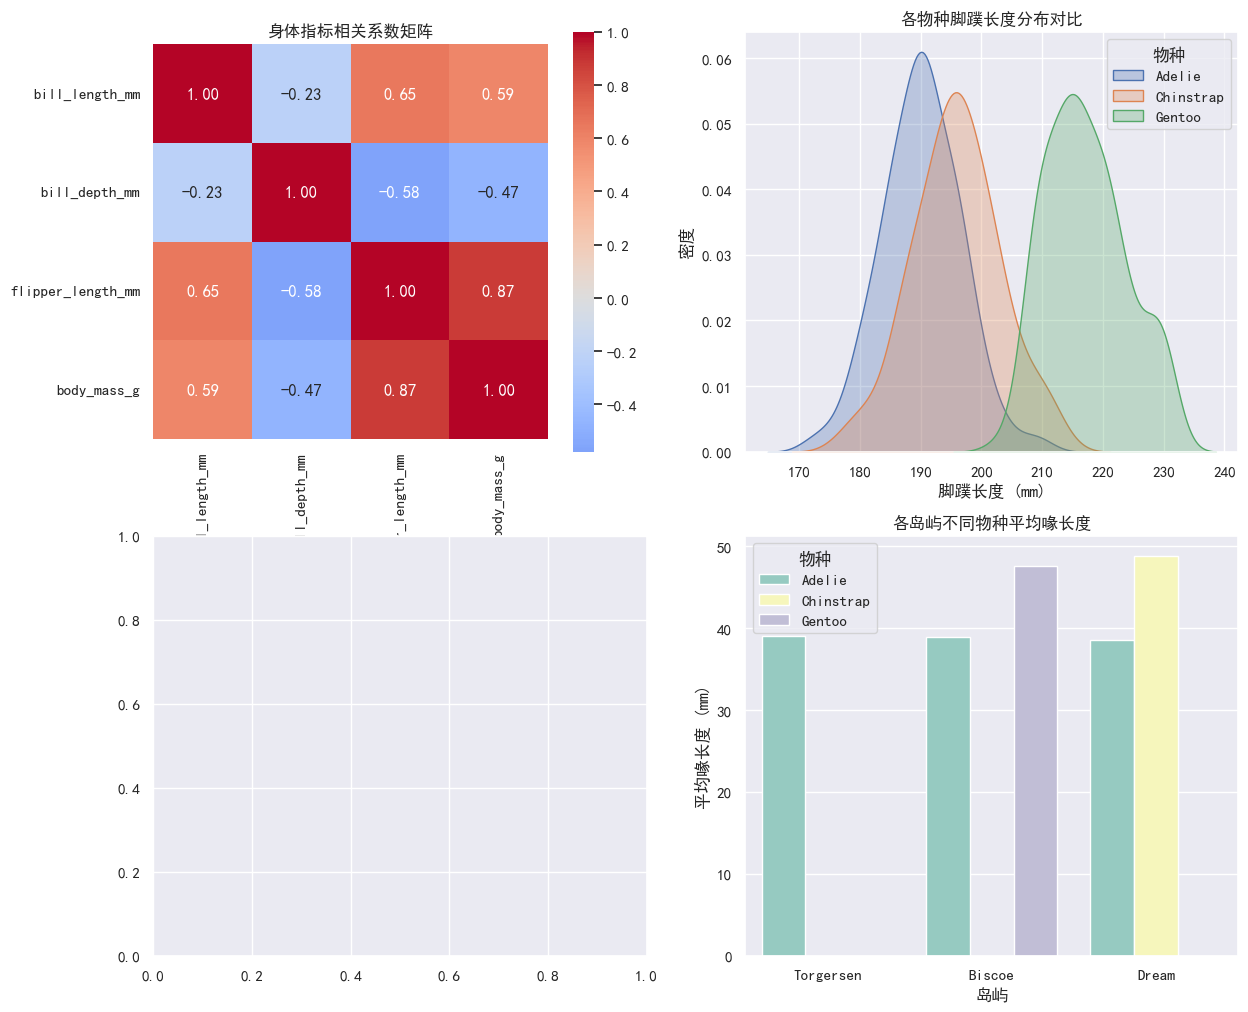

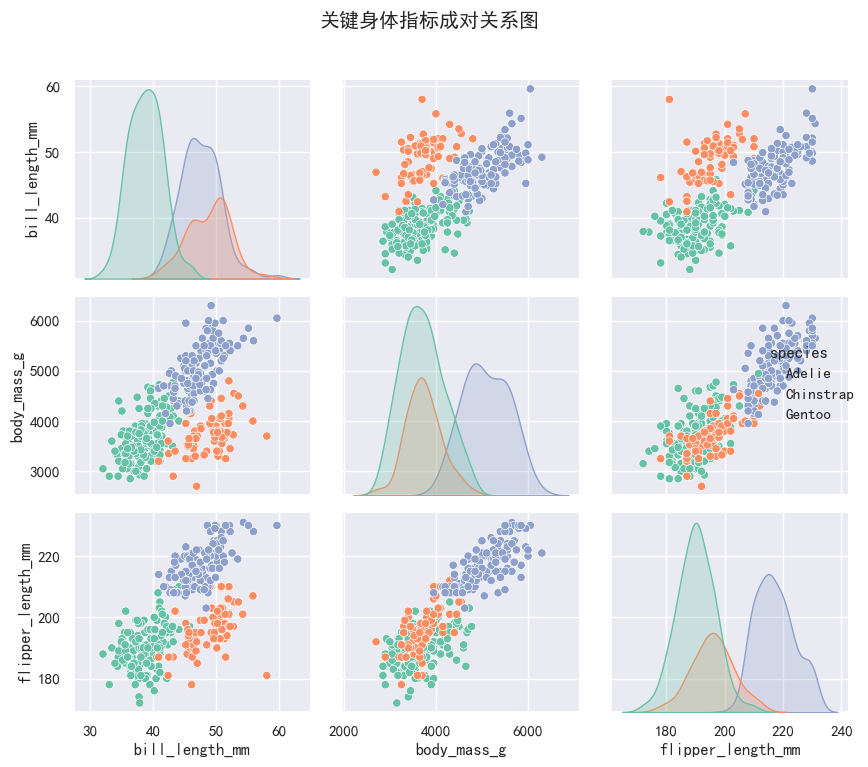

In [20]:
# 综合分析图 2：相关性分析与分布特征
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 2.1 身体指标相关系数热力图
num_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
corr_matrix = penguins[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0, 0], square=True, center=0)
axes[0, 0].set_title("身体指标相关系数矩阵")

# 2.2 各指标按物种分组的核密度估计
for species in penguins["species"].unique():
    subset = penguins[penguins["species"] == species]
    sns.kdeplot(data=subset, x="flipper_length_mm", ax=axes[0, 1], label=species, fill=True, alpha=0.3)
axes[0, 1].set_title("各物种脚蹼长度分布对比")
axes[0, 1].set_xlabel("脚蹼长度 (mm)")
axes[0, 1].set_ylabel("密度")
axes[0, 1].legend(title="物种")

# 2.3 成对关系图（选取关键变量）
key_vars = ["bill_length_mm", "body_mass_g", "flipper_length_mm"]
g = sns.pairplot(data=penguins, vars=key_vars, hue="species", palette="Set2", diag_kind="kde")
g.fig.suptitle("关键身体指标成对关系图", y=1.02)

# 2.4 各岛屿和物种的喙长度均值条形图
sns.barplot(data=penguins, x="island", y="bill_length_mm", hue="species", estimator="mean", errorbar=None, ax=axes[1, 1], palette="Set3")
axes[1, 1].set_title("各岛屿不同物种平均喙长度")
axes[1, 1].set_xlabel("岛屿")
axes[1, 1].set_ylabel("平均喙长度 (mm)")
axes[1, 1].legend(title="物种")

plt.tight_layout()
plt.show()

## 总结

本笔记系统介绍了 Seaborn 的核心绘图功能，涵盖了分布图表（直方图、核密度估计、地毯图）、计数图表（计数图、条形图）、散点图及相关图表（散点图、联合图、成对关系图）、二维核密度估计、箱线图、小提琴图、热力图以及样式与配色设置。通过企鹅数据集的综合案例，我们展示了如何将多种图表类型结合使用，从不同角度揭示数据的特征和规律。Seaborn 的设计理念是使用简洁的 API 创建美观且信息丰富的统计图表，这使得它成为数据分析和可视化工作中不可或缺的工具。